In [41]:
import numpy as np
import tensorflow as tf


In [42]:
data = np.load("/kaggle/input/fer-full-1/fer2013_full.npz", mmap_mode="r")

x_train = data["x_train"]
y_train = data["y_train"]
x_val   = data["x_val"]
y_val   = data["y_val"]
x_test  = data["x_test"]
y_test  = data["y_test"]

print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)


(22968, 48, 48, 1) (22968,)
(5741, 48, 48, 1) (5741,)


In [43]:
BATCH_SIZE = 128

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
val_ds   = tf.data.Dataset.from_tensor_slices((x_val, y_val))
test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))


In [44]:
train_ds = (
    train_ds
    .shuffle(2000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_ds
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_ds
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


In [45]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.05)
])


In [46]:
from tensorflow.keras import layers, models, optimizers

model = models.Sequential([
    # Layer Block 1
    layers.Conv2D(64, (3, 3), padding='same', input_shape=(48, 48, 1)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    # Layer Block 2
    layers.Conv2D(128, (5, 5), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    # Layer Block 3
    layers.Conv2D(256, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    # Layer Block 4
    layers.Conv2D(512, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.3),

    # Flatten and Dense layers
    layers.Flatten(),
    
    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.4),

    layers.Dense(512),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.4),

    # Output Layer
    layers.Dense(7, activation='softmax')
])

# Compilation
opt = optimizers.Adam(learning_rate=0.0005)
#model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

# Change this line in your model.compile:
model.compile(optimizer=opt, 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])
model.summary()



    




Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 24, 24, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 256)            │         1,02

 Total params: 3,002,887 (11.46 MB)

 Trainable params: 2,999,431 (11.44 MB)

 Non-trainable params: 3,456 (13.50 KB)

In [47]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

# 1. Define the Learning Rate reduction strategy
reduce_lr = ReduceLROnPlateau(monitor='val_loss', 
                              factor=0.1, 
                              patience=2, 
                              min_lr=0.00001, 
                              mode='auto')

# 2. Define the Checkpoint
checkpoint = ModelCheckpoint("cnn_github.keras", 
                             monitor='val_accuracy', 
                             save_best_only=True, 
                             mode='max', 
                             verbose=1)

# 3. Combine only the standard callbacks
callbacks = [checkpoint, reduce_lr]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    # class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/40
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.2123 - loss: 2.1466
Epoch 1: val_accuracy improved from -inf to 0.17436, saving model to cnn_github.keras
180/180 ━━━━━━━━━━━━━━━━━━━━ 26s 86ms/step - accuracy: 0.2124 - loss: 2.1460 - val_accuracy: 0.1744 - val_loss: 1.9469 - learning_rate: 5.0000e-04
Epoch 2/40
179/180 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.2941 - loss: 1.8335
Epoch 2: val_accuracy improved from 0.17436 to 0.19648, saving model to cnn_github.keras
180/180 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.2943 - loss: 1.8328 - val_accuracy: 0.1965 - val_loss: 1.9591 - learning_rate: 5.0000e-04
Epoch 3/40
179/180 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3701 - loss: 1.6336
Epoch 3: val_accuracy improved from 0.19648 to 0.36474, saving model to cnn_github.keras
180/180 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.3703 - loss: 1.6332 - val_accuracy: 0.3647 - val_loss: 1.6376 - learning_rate: 5.0000e-04
Epoch 4/40
179/180 ━━━━━━━━━━━━━━━━━

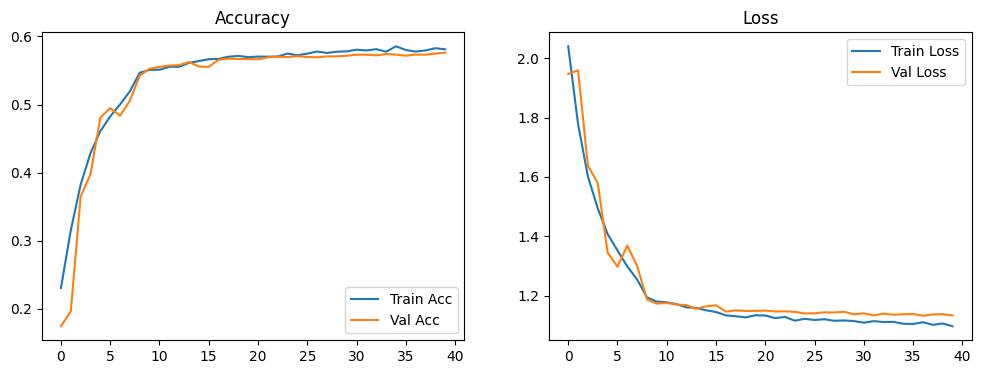

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

plt.show()


In [49]:
# Evaluate model on test set
test_loss, test_acc = model.evaluate(test_ds)

print(f"Test Accuracy: {test_acc * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4435 - loss: 1.3537
Test Accuracy: 57.22%
Test Loss: 1.1200


In [50]:
model.save("cnn_fer2013.keras")
